# Multi-Fidelity Gaussian Process Regression for Market Risk Calculation

**Authors:** CHAQUIQ ELBADRE Youssef — NOUV Ratanakmuny

### A reproduction study of Lehdili, Oswald & Nguyen (2025)
*Computation, 13(6), 134* — [link to paper](https://www.mdpi.com/2079-3197/13/6/134)

---

## Abstract

Under the FRTB regulation, banks must compute Value-at-Risk (VaR) and Expected Shortfall (ES) every day for each trading portfolio. The standard procedure requires repricing the portfolio across $M = 100{,}000$ market scenarios, with each repricing involving an expensive Monte Carlo simulation. This is computationally prohibitive in practice.

Lehdili et al. (2025) propose using **Gaussian Process Regression** (GPR) as a fast surrogate for the pricing engine, and further introduce a **multi-fidelity** variant (mGPR) based on the autoregressive AR(1) co-kriging of Kennedy & O'Hagan (2000). The idea is to combine a small set of expensive but accurate prices with a larger set of cheap but noisy prices.

This notebook reproduces the experiments of Section 6.2 of the paper for a **5-asset geometric average call**, investigates the sensitivity of the multi-fidelity coupling parameter $\rho$ to implementation choices (raw vs. de-noised LF signal, number of LF Monte Carlo paths), and validates the implementation on an **American put option** (Section 4.3 of the paper) where the low-fidelity model is deterministic.


## 1. Background

### 1.1 Market Risk Under FRTB

Under the Basel III / FRTB framework, banks must report two risk metrics for each trading book:

- **Value-at-Risk** at confidence level $\alpha = 99\%$: the loss that will not be exceeded with probability $\alpha$.
- **Expected Shortfall** at $\alpha = 97.5\%$: the expected loss given that it exceeds VaR.

If $V_t = p_t(\mathrm{RF}_t)$ denotes the portfolio value at date $t$ as a function of risk factors $\mathrm{RF}_t$, the loss over horizon $h$ is

$$L_t(h) = V_t - V_{t+h} = p_t(\mathrm{RF}_t) - p_t(\mathrm{RF}_t + \Delta\mathrm{RF}_h),$$

and VaR/ES are estimated empirically from the loss distribution simulated over $M$ scenarios.

### 1.2 The Computational Challenge

The bottleneck is Step 3 of the standard procedure: for each of the $M = 100{,}000$ outer scenarios, the pricing engine $p_t(\cdot)$ must be called once. When $p_t$ is itself a Monte Carlo simulation with $N_{\text{paths}} = 100{,}000$ inner paths, the total cost is $M \times N_{\text{paths}} = 10^{10}$ path evaluations per portfolio per day. Banks need a faster alternative.

### 1.3 Surrogate Models with Gaussian Processes

The idea proposed in the paper is to replace $p_t(\cdot)$ by a Gaussian Process surrogate $\hat{p}_t(\cdot)$ trained on a small number $N \ll M$ of expensive evaluations. The trained surrogate can predict the remaining $M - N$ prices at negligible cost. The multi-fidelity extension reduces the training cost further by combining a few high-fidelity prices with many low-fidelity ones.


## 2. Theory

### 2.1 Standard Gaussian Process Regression

Given $N$ training observations $\mathcal{D} = \{(x_i, y_i)\}_{i=1}^N$ with $y_i = f(x_i) + \varepsilon_i$ and $\varepsilon_i \sim \mathcal{N}(0, \sigma^2)$, we place a GP prior on $f$:

$$f \sim \mathcal{GP}\bigl(m(x),\, k(x, x')\bigr).$$

For any new point $x^*$, the posterior distribution of $f(x^*)$ is Gaussian with mean and variance

$$\bar{f}(x^*) = m(x^*) + k_*^\top (K + \sigma^2 I)^{-1}(\mathbf{y} - m_X),$$
$$\mathrm{Var}[f(x^*)] = k(x^*, x^*) - k_*^\top (K + \sigma^2 I)^{-1} k_*.$$

We use the **Matérn 5/2 kernel** throughout (Section 5.2 of the paper), which models functions that are twice differentiable — a good match for option pricing surfaces.

### 2.2 The Multi-Fidelity AR(1) Model (Kennedy & O'Hagan, 2000)

The autoregressive model relates the high-fidelity function $f^h$ to the low-fidelity function $f^l$ via

$$\boxed{\, f^h(x) = \rho \, f^l(x) + \delta(x), \qquad f^l \perp \delta \mid x. \,}$$

Here $\rho \in \mathbb{R}$ is a scalar correlation coefficient and $\delta(x)$ is an independent **discrepancy** GP. Both $f^l$ and $\delta$ are modeled as Gaussian processes with their own Matérn 5/2 kernels.

**The conditional independence assumption is crucial**: it allows us to train the model in two separate steps instead of one large joint optimization.

#### Training procedure (Appendix B.2 of the paper)

1. **Train $f^l$** on the low-fidelity data $(X_l, y_l)$ by maximizing its own marginal log-likelihood. This yields $\hat{\theta}_l$ — Eq. (A8).

2. **Optimize $\rho$ and $\theta_\delta$** by maximizing the marginal log-likelihood of the residual GP — Eq. (A9):
$$\hat{\rho}, \hat{\theta}_\delta = \arg\max_{\rho, \theta_\delta} \log p\bigl(\mathbf{d}(\rho) \mid X_h, \theta_\delta\bigr), \qquad \mathbf{d}(\rho) = \mathbf{y}_h - \rho \, \mathbf{y}_{l,\text{sub}}.$$

3. **Train $\delta$** on $(X_h, \mathbf{d}(\hat{\rho}))$ with the optimal $\hat{\rho}$.

#### Prediction

For a new point $x^*$, the multi-fidelity prediction is

$$\hat{f}^h(x^*) = \hat{\rho} \cdot \mu_l(x^*) + \mu_\delta(x^*),$$

where $\mu_l, \mu_\delta$ are the posterior means of the LF and discrepancy GPs.

### 2.3 Training–Prediction Asymmetry

An important subtlety: the paper's training formula uses **raw LF observations** $y_{l,\text{sub}}$ to form the residual, but the prediction formula uses **the LF GP posterior mean** $\mu_l(x^*)$ because raw observations are not available at new test points. When the LF source is noisy (e.g., Monte Carlo with few paths), $y_{l,\text{sub}}$ and $\mu_l(X_h)$ can differ substantially. This asymmetry has practical consequences for the estimated $\rho$, which we investigate in Section 8.


## 3. Implementation Setup

We use:
- **NumPy / SciPy** for numerics and pricing engines
- **scikit-learn** for the standard GPR baseline (`GaussianProcessRegressor`)
- **GPflow** for the multi-fidelity GPR (we build the AR(1) co-kriging on top of GPflow's `GPR` class)

GPflow is preferred over GPyTorch here because its `Scipy` optimizer wraps `scipy.optimize.minimize` with deterministic L-BFGS-B, which is essential for the outer optimization of $\rho$ to converge reliably.

### For Colab that install the `gpflow` for the first time

**After you run the installation, please restart the runtime and run all to avoid the import errors.**

In [ ]:
# Install GPflow on Colab (uncomment if needed)
try:
    import gpflow
    print("GPflow are already installed.")
except ImportError:
    print("Packages missing. Installing...")
    !pip install -q "numpy<2.0.0" gpflow
    # Restart the kernel after installation to avoid import errors.


GPflow are already installed.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time, copy, warnings
warnings.filterwarnings("ignore")

from scipy.stats import norm
from scipy.optimize import minimize_scalar
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C, WhiteKernel
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
import gpflow

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
gpflow.config.set_default_float(np.float64)

print("NumPy       :", np.__version__)
print("TensorFlow  :", tf.__version__)
print("GPflow      :", gpflow.__version__)





NumPy       : 1.26.4
TensorFlow  : 2.21.0
GPflow      : 2.10.0


## 4. Financial Model

### 4.1 Test Instrument: 5-Asset Geometric Call

We follow Section 6.2 of the paper and consider a European call on the **geometric average** of $d = 5$ correlated stocks:

$$\eta(S_T) = \left(\bigl(\textstyle\prod_{j=1}^d S_T^j\bigr)^{1/d} - K\right)^+.$$

Each underlying follows a geometric Brownian motion under the risk-neutral measure:

$$dS_t^j = r\, S_t^j\, dt + \sigma^j\, S_t^j\, dW_t^j, \qquad d\langle W^j, W^{j'}\rangle_t = \rho_{jj'}\,dt.$$

We chose it because the geometric mean of lognormal variables is itself lognormal, the price has a closed-form Black-Scholes expression. This gives us an exact reference to validate the surrogate models against, eliminating Monte Carlo noise from the evaluation.


In [3]:
# === Market parameters ===

d = 5
S0    = np.array([90.0, 95.0, 99.0, 100.0, 97.0])
sigma = np.array([0.40, 0.20, 0.30, 0.15, 0.25])

r     = 0.01    # risk-free rate
T_mat = 2.0     # option maturity (years)
K     = 100.0   # strike

corr_matrix = np.array([
    [1.0   , 0.0233, 0.1572, 0.1982, 0.1659],
    [0.0233, 1.0   , 0.3209, 0.3487, 0.1969],
    [0.1572, 0.3209, 1.0   , 0.0291, 0.3990],
    [0.1982, 0.3487, 0.0291, 1.0   , 0.1136],
    [0.1659, 0.1969, 0.3990, 0.1136, 1.0   ]
], dtype=float)

# Risk parameters
h = 1.0 / 252      # 1-day risk horizon
M = 100_000        # number of outer scenarios for VaR/ES

# Two fidelity levels (Section 6.2: MC_LF = 100)
MC_HF = 100_000
MC_LF = 100

print(f"Test instrument : geometric average call on {d} assets")
print(f"Maturity        : {T_mat} years, Strike = {K}")
print(f"Risk horizon    : {h*252:.0f} day(s)")
print(f"Outer scenarios : M = {M:,}")
print(f"HF paths        : {MC_HF:,}")
print(f"LF paths        : {MC_LF:,}")


Test instrument : geometric average call on 5 assets
Maturity        : 2.0 years, Strike = 100.0
Risk horizon    : 1 day(s)
Outer scenarios : M = 100,000
HF paths        : 100,000
LF paths        : 100


### 4.2 Pricing Engines

**Black-Scholes (analytical reference).** The geometric mean $G_T = (\prod_j S_T^j)^{1/d}$ is lognormal with effective volatility

$$\sigma_{\text{geo}}^2 = \frac{1}{d^2} \sum_{i,j} \sigma_i \sigma_j \rho_{ij}.$$

The price is then given by the standard Black formula applied to the forward of $G_T$.

**Monte Carlo (the bank's pricing engine).** We simulate $N_{\text{paths}}$ correlated terminal stock vectors using a Cholesky decomposition of the correlation matrix, evaluate the payoff on each path, and average. This is the engine that the surrogate replaces.


In [ ]:
# === Black-Scholes price for the geometric call ===

def price_geom_call_bs(S, K, T, r, sigma, corr_matrix):
    """
    Closed-form Black-Scholes price of a geometric average call.
    
    The payoff is max(G_T - K, 0) where G_T = (prod(S_T^j))^(1/d).
    Since G_T is lognormal, we can price using a Black formula with
    adjusted volatility and drift.
    
    Accepts S as either a single vector (d,) or a batch (n_scenarios, d).
    """
    # Handle single vs batch input
    is_single = (S.ndim == 1)
    if is_single:
        S = S.reshape(1, -1)
    d_assets = S.shape[1]
    
    # --- Effective volatility of the geometric mean ---
    sigma_geo_sq = np.einsum('i,j,ij->', sigma, sigma, corr_matrix) / d_assets**2
    sigma_geo    = np.sqrt(sigma_geo_sq)

    # --- Forward price of the geometric mean ---
    log_F = np.sum(np.log(S) + (r - 0.5 * sigma**2) * T, axis=1) / d_assets + 0.5 * sigma_geo_sq * T
    F     = np.exp(log_F)

    # --- Black formula for the call option ---
    d1 = (np.log(F / K) + 0.5 * sigma_geo_sq * T) / (sigma_geo * np.sqrt(T))
    d2 = d1 - sigma_geo * np.sqrt(T)
    price = np.exp(-r * T) * (F * norm.cdf(d1) - K * norm.cdf(d2))

    # Return scalar if input was single vector, else array
    return float(price[0]) if is_single else price


# === Monte Carlo price for the geometric call ===

def price_geom_call_mc(S_batch, K, T, r, sigma, corr_matrix, n_paths, seed=0):
    """
    Monte Carlo price of a geometric call for a batch of starting points.
    
    For each scenario in S_batch, simulates n_paths correlated terminal prices
    under the risk-neutral GBM, computes the geometric average payoff, and averages.
    
    Parameters
    ----------
    S_batch : array, shape (n_scenarios, d)
        Initial stock prices for each scenario.
    K, T, r, sigma, corr_matrix : floats/arrays
        Strike, maturity, risk-free rate, volatilities, correlation matrix.
    n_paths : int
        Number of Monte Carlo paths per scenario.
    seed : int
        Random seed for reproducibility.
    
    Returns
    -------
    prices : array, shape (n_scenarios,)
        Discounted expected payoff for each scenario.
    """
    rng = np.random.default_rng(seed)
    n_scenarios, d_assets = S_batch.shape
    
    # Cholesky decomposition for correlated sampling
    L = np.linalg.cholesky(corr_matrix)
    prices = np.empty(n_scenarios)

    # Loop over scenarios (memory-friendly when n_paths is large)
    for i in range(n_scenarios):
        # Generate correlated standard normals
        Z   = rng.standard_normal((n_paths, d_assets)) @ L.T

        # Simulate terminal stock prices under risk-neutral GBM
        S_T = S_batch[i] * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
        
        # Compute geometric average and option payoff
        G_T = np.prod(S_T, axis=1) ** (1.0 / d_assets)
        
        # Price: discounted expected payoff
        # C = exp(-r*T) * E[max(G_T - K, 0)]
        prices[i] = np.exp(-r * T) * np.mean(np.maximum(G_T - K, 0.0))

    return prices


In [5]:
# === Sanity check: BS price vs MC price at the initial point ===

p_bs    = price_geom_call_bs(S0, K, T_mat, r, sigma, corr_matrix)
p_mc_hf = price_geom_call_mc(S0.reshape(1, -1), K, T_mat, r, sigma, corr_matrix, MC_HF, seed=0)[0]
p_mc_lf = price_geom_call_mc(S0.reshape(1, -1), K, T_mat, r, sigma, corr_matrix, MC_LF, seed=0)[0]

print(f"BS exact price            : {p_bs:.6f}")
print(f"MC high-fidelity ({MC_HF:,})  : {p_mc_hf:.6f}  (rel. error {abs(p_mc_hf-p_bs)/p_bs*100:.4f}%)")
print(f"MC low-fidelity  ({MC_LF:,})     : {p_mc_lf:.6f}  (rel. error {abs(p_mc_lf-p_bs)/p_bs*100:.4f}%)")


BS exact price            : 5.535462
MC high-fidelity (100,000)  : 5.559617  (rel. error 0.4364%)
MC low-fidelity  (100)     : 4.388801  (rel. error 20.7148%)


### 4.3 Risk Scenarios and Reference Prices

We simulate $M = 100{,}000$ shocked stock vectors at the 1-day horizon using the diffusion model

$$S_h^j = S_0^j \exp\!\left[\left(r - \tfrac{(\sigma^j)^2}{2}\right)h + \sigma^j \sqrt{h}\, Z^j\right], \quad Z \sim \mathcal{N}(0, R).$$

For each shocked vector we compute the **true** option price via the BS formula. This gives us:
- The full distribution of true prices (used to evaluate surrogate accuracy)
- The reference loss distribution $L = V_0 - V_h$ (used to compute the true VaR and ES)

In [6]:
# === Generate M outer risk scenarios ===

rng = np.random.default_rng(SEED)
L_chol = np.linalg.cholesky(corr_matrix)

# Correlated standard normals
Z = rng.standard_normal((M, d)) @ L_chol.T

# Shocked stock prices at h = 1 day
S_shocked = S0 * np.exp((r - 0.5 * sigma**2) * h + sigma * np.sqrt(h) * Z)

print(f"Generated {M:,} risk scenarios, shape = {S_shocked.shape}")

# === Compute true prices via BS for all scenarios ===
prices_true = price_geom_call_bs(S_shocked, K, T_mat, r, sigma, corr_matrix)

# Initial price and reference loss distribution
V0          = price_geom_call_bs(S0, K, T_mat, r, sigma, corr_matrix)
losses_true = V0 - prices_true

# True risk metrics
var_99_true = np.percentile(losses_true, 99)
es_975_true = losses_true[losses_true >= np.percentile(losses_true, 97.5)].mean()

print(f"\nInitial price V0 : {V0:.6f}")
print(f"True VaR 99%     : {var_99_true:.6f}")
print(f"True ES  97.5%   : {es_975_true:.6f}")


Generated 100,000 risk scenarios, shape = (100000, 5)

Initial price V0 : 5.535462
True VaR 99%     : 0.850201
True ES  97.5%   : 0.848325


### 4.4 Training Data Generation

We use **Common Random Numbers (CRN)**: for each shared training point, the LF and HF prices use the same underlying Gaussian samples (LF uses the first `mc_lf` paths, HF uses all `mc_hf` paths). This ensures positive correlation between LF and HF, which is essential for the AR(1) model.


In [ ]:
def price_geom_call_mc_from_Z(S_batch, K, T, r, sigma, corr_matrix, Z):
    """
    Monte Carlo price of a geometric average call option using pre-generated random numbers.
    
    This function computes option prices for one or more initial stock vectors using
    a geometric Brownian motion (GBM) simulation driven by a supplied random matrix Z.
    It evaluates the payoff of a European call on the geometric mean of d assets.
    
    The key feature is that Z is pre-generated externally, allowing callers to control
    the random seed and reuse the same Z for both low-fidelity (LF) and high-fidelity (HF)
    pricing via common random numbers (CRN) — using the first mc_lf rows for LF and the 
    first mc_hf rows for HF ensures correlation between LF and HF prices.
    
    Payoff: max(G_T - K, 0) where G_T = (product of d terminal stock prices)^(1/d)
    Price: exp(-r*T) * E[payoff]

    Parameters
    ----------
    S_batch : array, shape (n_scenarios, d)
        Initial stock price vectors. Each row is the starting price for one scenario.
    K : float
        Strike price of the call option.
    T : float
        Time to maturity (in years).
    r : float
        Risk-free interest rate.
    sigma : array, shape (d,)
        Volatility (annualized) for each of the d assets.
    corr_matrix : array, shape (d, d)
        Correlation matrix of the d assets (must be positive semi-definite).
    Z : array, shape (n_paths, d)
        Pre-generated standard normal random matrix (one row per path).

    Returns
    -------
    prices : array, shape (n_scenarios,)
        Discounted expected payoff for each scenario.
    """
    # Convert inputs to float64 arrays
    S_batch = np.asarray(S_batch, dtype=np.float64)
    Z = np.asarray(Z, dtype=np.float64)

    # Extract dimensions
    n_scenarios, d_assets = S_batch.shape
    prices = np.empty(n_scenarios, dtype=np.float64)

    # Pre-compute GBM parameters
    drift = (r - 0.5 * sigma**2) * T
    vol   = sigma * np.sqrt(T)

    # Price each scenario independently
    for i in range(n_scenarios):
        # Simulate terminal stock prices for all paths using the pre-generated Z
        S_T = S_batch[i] * np.exp(drift + vol * Z)
        
        # Compute geometric average across assets
        G_T = np.prod(S_T, axis=1) ** (1.0 / d_assets)
        
        # Calculate discounted call payoff: exp(-r*T) * E[max(G_T - K, 0)]
        prices[i] = np.exp(-r * T) * np.mean(np.maximum(G_T - K, 0.0))
    
    return prices


def paired_mc_price_one_point(S, K, T, r, sigma, corr_matrix, mc_lf, mc_hf, seed):
    """
    Compute matched low-fidelity and high-fidelity prices for a single stock vector.
    
    This function implements the core idea of common random numbers (CRN): it generates
    a single sequence of correlated random samples and uses the first mc_lf rows to
    price the low-fidelity model and all mc_hf rows to price the high-fidelity model.
    This ensures strong positive correlation between LF and HF prices, which is essential
    for the multi-fidelity AR(1) co-kriging model to work well.
    
    The function is called once per shared training point and returns a (y_lf, y_hf) pair.

    Parameters
    ----------
    S : array, shape (d,)
        Initial stock price vector for this point.
    K : float
        Strike price.
    T : float
        Time to maturity.
    r : float
        Risk-free rate.
    sigma : array, shape (d,)
        Volatilities of the d assets.
    corr_matrix : array, shape (d, d)
        Correlation matrix.
    mc_lf : int
        Number of paths for low-fidelity value.
    mc_hf : int
        Number of paths for high-fidelity value (mc_hf >= mc_lf).
    seed : int
        Random seed for reproducibility.

    Returns
    -------
    y_lf, y_hf : float, float
        Low-fidelity and high-fidelity prices for the same underlying point.
    """
    d_assets = len(S)

    # Generate a single set of correlated random numbers
    rng = np.random.default_rng(seed)
    L = np.linalg.cholesky(corr_matrix)
    Z = rng.standard_normal((mc_hf, d_assets)) @ L.T

    # Price LF and HF using the same random matrix (first mc_lf vs all mc_hf rows)
    y_lf = price_geom_call_mc_from_Z(S.reshape(1, -1), K, T, r, sigma, corr_matrix, Z[:mc_lf])[0]
    y_hf = price_geom_call_mc_from_Z(S.reshape(1, -1), K, T, r, sigma, corr_matrix, Z[:mc_hf])[0]
    
    return y_lf, y_hf


def generate_training_data(S_pool, N_hf, N_lf, K, T, r, sigma, corr_matrix,
                           mc_hf=100_000, mc_lf=100, seed=42, verbose=True):
    """
    Generate a multi-fidelity training dataset with structured design.
    
    This function creates a training set suitable for multi-fidelity Gaussian process
    regression. The core design principle is that the first N_hf points (which are computationally
    expensive) are priced at both HF and LF fidelities using common random numbers (CRN).
    The remaining N_lf - N_hf points are priced only at LF (cheap MC with few paths).
    
    The CRN strategy ensures positive correlation between LF and HF prices, which is crucial
    for the AR(1) co-kriging model: f_h(x) = rho * f_l(x) + delta(x). If LF and HF were
    uncorrelated or negatively correlated, the model would collapse to rho ≈ 0 and ignore
    the LF data.
    
    Design:
    - X_hf = X_lf[:N_hf] (first N_hf points are shared)
    - Points 0..N_hf-1: Use CRN to get both y_lf and y_hf with same seed offset
    - Points N_hf..N_lf-1: Use fresh MC seeds, compute y_lf only at low cost

    Parameters
    ----------
    S_pool : array, shape (M, d)
        Pool of stock vectors to sample from (e.g., shocked initial conditions).
    N_hf : int
        Number of high-fidelity training points (expensive).
    N_lf : int
        Total number of low-fidelity training points (cheap). Must be >= N_hf.
    K : float
        Strike price.
    T : float
        Time to maturity.
    r : float
        Risk-free rate.
    sigma : array, shape (d,)
        Volatilities of the d assets.
    corr_matrix : array, shape (d, d)
        Correlation matrix.
    mc_hf : int, optional
        Number of MC paths for HF pricing (default 100,000).
    mc_lf : int, optional
        Number of MC paths for LF pricing (default 100). Smaller mc_lf gives noisier
        but cheaper LF prices. Smaller mc_lf is more realistic for the low-fidelity
        model but increases noise in the training signal.
    seed : int, optional
        Base random seed (default 42). Incremented for each point to ensure reproducibility.
    verbose : bool, optional
        If True, print generation progress and correlation(y_lf_sub, y_hf).

    Returns
    -------
    X_hf : array, shape (N_hf, d)
        Initial stock vectors for HF training points.
    y_hf : array, shape (N_hf,)
        High-fidelity prices (MC with mc_hf paths).
    X_lf : array, shape (N_lf, d)
        Initial stock vectors for all LF training points (X_hf as first N_hf rows).
    y_lf : array, shape (N_lf,)
        Low-fidelity prices (MC with mc_lf paths). First N_hf entries use CRN with HF.
    """
    # Validate constraint
    assert N_hf <= N_lf
    
    # Sample N_lf points from the pool
    rng = np.random.default_rng(seed)
    idx_lf = rng.choice(S_pool.shape[0], size=N_lf, replace=False)
    X_lf = S_pool[idx_lf].copy()
    
    # First N_hf points are marked as HF training points
    X_hf = X_lf[:N_hf].copy()
    
    # Initialize output arrays
    y_lf = np.empty(N_lf, dtype=np.float64)
    y_hf = np.empty(N_hf, dtype=np.float64)
    L = np.linalg.cholesky(corr_matrix)

    if verbose:
        print(f"Generating: N_hf={N_hf}, N_lf={N_lf}, mc_lf={mc_lf}, mc_hf={mc_hf}")
    t0 = time.time()

    # Shared points: compute both LF and HF prices using common random numbers
    for j in range(N_hf):
        yl, yh = paired_mc_price_one_point(X_hf[j], K, T, r, sigma, corr_matrix, mc_lf, mc_hf, seed + j)
        y_lf[j], y_hf[j] = yl, yh

    # LF-only points: compute only cheap LF prices
    for j in range(N_hf, N_lf):
        rng_j = np.random.default_rng(seed + j)
        Z = rng_j.standard_normal((mc_lf, X_lf.shape[1])) @ L.T
        y_lf[j] = price_geom_call_mc_from_Z(X_lf[j].reshape(1, -1), K, T, r, sigma, corr_matrix, Z)[0]

    if verbose:
        print(f"Done in {time.time() - t0:.1f}s  |  corr(y_lf_sub, y_hf) = {np.corrcoef(y_lf[:N_hf], y_hf)[0,1]:.4f}")
    return X_hf, y_hf, X_lf, y_lf

## 5. Standard GPR Surrogate (scikit-learn)

We use scikit-learn's `GaussianProcessRegressor` with a Matérn 5/2 kernel. Hyperparameters are estimated by L-BFGS-B with five random restarts (Section 5.2 of the paper). Inputs are standardized.


In [ ]:
def fit_gpr_sklearn(X_train, y_train, n_restarts=5):
    """
    Fit a standard Gaussian Process Regressor with Matérn 5/2 kernel.
    
    This is the baseline surrogate model that will be compared against multi-fidelity GPR.
    It uses scikit-learn's GaussianProcessRegressor with:
    - A composite kernel: (Constant * Matérn-5/2) + WhiteKernel
    - StandardScaler for input normalization
    - Multiple restarts (L-BFGS-B optimizer) to avoid local minima
    - Output normalization (normalize_y=True)
    
    Parameters
    ----------
    X_train : array, shape (n_train, d)
        Training input features (will be standardized internally).
    y_train : array, shape (n_train,)
        Training targets (prices).
    n_restarts : int, optional
        Number of random restarts for hyperparameter optimization (default 5).
    
    Returns
    -------
    gp : GaussianProcessRegressor
        Fitted scikit-learn GPR model.
    scaler : StandardScaler
        Fitted scaler for transforming new inputs.
    """
    # Standardize training inputs to zero mean and unit variance
    scaler = StandardScaler().fit(X_train)
    X_s    = scaler.transform(X_train)
    
    # Define composite kernel: amplitude-scaled Matérn 5/2 plus white noise
    # - C(1.0, ...): constant factor (amplitude) with hyperprior bounds
    # - Matern(..., nu=2.5): Matérn kernel with polynomial order 5/2 (twice differentiable)
    # - WhiteKernel(...): additive Gaussian noise term (regularization)
    kernel = (
        C(1.0, (1e-3, 1e3)) *
        Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5)
        + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-10, 1e-1))
    )
    
    # Create and fit the GPR model
    gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=n_restarts,
                                   normalize_y=True, random_state=SEED)
    gp.fit(X_s, y_train)
    
    return gp, scaler


def predict_gpr_sklearn(gp, scaler, X_new):
    """
    Make predictions with a fitted GPR model.
    
    Applies the same standardization to new inputs before prediction.
    
    Parameters
    ----------
    gp : GaussianProcessRegressor
        Fitted model.
    scaler : StandardScaler
        Fitted scaler (same as returned by fit_gpr_sklearn).
    X_new : array, shape (n_new, d)
        New input points.
    
    Returns
    -------
    preds : array, shape (n_new,)
        Predicted values (posterior means).
    """
    return gp.predict(scaler.transform(X_new))


def evaluate_surrogate(preds, prices_true, V0):
    """
    Evaluate surrogate model accuracy on risk metrics.
    
    Computes three quantities for model comparison:
    - MAPE: Mean Absolute Percentage Error (pricing accuracy)
    - VaR 99%: Value-at-Risk at 99th percentile (tail risk)
    - ES 97.5%: Expected Shortfall (expected loss in tail)
    
    Parameters
    ----------
    preds : array, shape (n_scenarios,)
        Predicted option prices from surrogate.
    prices_true : array, shape (n_scenarios,)
        True option prices (from BS formula).
    V0 : float
        Initial portfolio value (reference for MAPE normalization).
    
    Returns
    -------
    mape : float
        Mean absolute percentage error relative to V0.
    var_99 : float
        VaR at 99th percentile of loss distribution.
    es_975 : float
        Expected shortfall (expected loss given VaR at 97.5%).
    """
    # Calculate pricing error as percentage of initial value
    mape   = np.mean(np.abs(preds - prices_true) / V0)
    
    # Convert prices to losses: L = V0 - P (higher price = lower loss)
    losses = V0 - preds
    
    # Compute tail risk metrics
    var_99 = np.percentile(losses, 99)
    es_975 = losses[losses >= np.percentile(losses, 97.5)].mean()
    
    return mape, var_99, es_975


## 6. Multi-Fidelity GPR via AR(1) Co-Kriging (GPflow)

We implement the Kennedy & O'Hagan AR(1) model following the paper's Appendix B.2.

**We provide two variants** of the $\rho$ estimation, which differ only in what signal is used to form the residual during training:

| Variant | Residual used for training | Relation to the paper | Prediction |
|---|---|---|---|
| `fit_mgpr_raw` | $d = y_h - \rho\, y_{l,\text{sub}}$ | Paper-faithful; follows Appendix B.2 / Eq. (A9) | $\hat f_h(x^*) = \rho \hat\mu_l(x^*) + \hat\mu_\delta(x^*)$ |
| `fit_mgpr_denoised` | $d = y_h - \rho\, \hat\mu_l(X_h)$ | Modified; replaces raw LF observations with the LF GP posterior mean at HF locations | $\hat f_h(x^*) = \rho \hat\mu_l(x^*) + \hat\mu_\delta(x^*)$ |


Both variants share the same `fit_gpflow_gp` building block and the same prediction function.


In [ ]:
def fit_gpflow_gp(X, y, maxiter=200, n_restarts=5, seed=42):
    """
    Fit a Gaussian Process Regressor using GPflow with Matérn 5/2 kernel.
    
    This function uses GPflow (TensorFlow backend) to train a GP with:
    - Matérn 5/2 kernel (twice differentiable, suitable for smooth functions)
    - Zero mean function
    - Deterministic L-BFGS-B optimization via Scipy wrapper
    - Multiple random restarts to avoid local minima
    
    GPflow is preferred over scikit-learn for multi-fidelity modeling because:
    - Its Scipy optimizer is deterministic and reliable for outer loop optimization
    - Custom models (like AR(1) co-kriging) are easier to build in GPflow
    - Better control over hyperparameter initialization and optimization
    
    Parameters
    ----------
    X : array, shape (n, d)
        Training inputs.
    y : array, shape (n,) or (n, 1)
        Training targets.
    maxiter : int, optional
        Maximum iterations for L-BFGS-B (default 200).
    n_restarts : int, optional
        Number of random restarts (default 5).
    seed : int, optional
        Random seed for reproducibility.
    
    Returns
    -------
    best_model : gpflow.models.GPR
        Best (lowest training loss) fitted GPR model.
    """
    # Convert inputs to float64 and reshape targets to 2D
    X = np.asarray(X, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64).reshape(-1, 1)
    
    # Track best model across restarts
    best_model, best_obj = None, np.inf
    rng = np.random.default_rng(seed)

    # Multiple random initializations to avoid local minima
    for _ in range(n_restarts):
        # Create GPR with Matérn 5/2 kernel
        kernel = gpflow.kernels.Matern52(lengthscales=1.0)
        model = gpflow.models.GPR(data=(X, y), kernel=kernel, mean_function=None)
        
        # Randomly initialize hyperparameters in log-space
        # Lengthscales: sample from log-uniform(log(0.2), log(5.0))
        model.kernel.lengthscales.assign(float(np.exp(rng.uniform(np.log(0.2), np.log(5.0)))))
        
        # Kernel variance: sample from log-uniform(log(0.5), log(2.0))
        model.kernel.variance.assign(float(np.exp(rng.uniform(np.log(0.5), np.log(2.0)))))
        
        # Likelihood variance (noise): sample from log-uniform(log(1e-6), log(1e-3))
        model.likelihood.variance.assign(float(np.exp(rng.uniform(np.log(1e-6), np.log(1e-3)))))
        
        # Optimize hyperparameters using bounded L-BFGS-B
        try:
            gpflow.optimizers.Scipy().minimize(
                model.training_loss, model.trainable_variables, options={"maxiter": maxiter})
            
            # Evaluate final training loss
            obj = float(model.training_loss().numpy())
            
            # Keep track of best model
            if np.isfinite(obj) and obj < best_obj:
                best_obj, best_model = obj, copy.deepcopy(model)
        except Exception:
            # Skip this restart if optimization fails
            continue

    # Fallback: if all restarts failed, create a basic model
    if best_model is None:
        best_model = gpflow.models.GPR(data=(X, y), kernel=gpflow.kernels.Matern52(lengthscales=1.0), mean_function=None)
        best_model.likelihood.variance.assign(1e-4)
    
    return best_model


def _optimize_rho(neg_lml_fn, verbose=False):
    """
    Find the optimal coupling parameter rho using two-stage optimization.
    
    Strategy:
    1. Grid search over 41 evenly spaced points in [0, 2]
    2. Local refinement using bounded L-BFGS-B near the grid optimum
    
    This hybrid approach balances robustness (grid search avoids gross misses)
    with efficiency (bounded refinement is fast).
    
    Parameters
    ----------
    neg_lml_fn : callable
        Function that evaluates negative marginal log-likelihood for a given rho.
        Should return a finite number or 1e12 (penalty for failure).
    verbose : bool, optional
        If True, print the optimal rho value.
    
    Returns
    -------
    rho : float
        Optimal coupling parameter in [0, 2].
    """
    # Stage 1: Coarse grid search
    grid = np.linspace(0.0, 2.0, 41)
    vals = np.array([neg_lml_fn(r) for r in grid])
    rho0 = float(grid[np.argmin(vals)])
    
    # Stage 2: Local refinement around grid optimum
    # Define bounds as ±0.2 around grid optimum (but stay within [0, 2])
    lo, hi = max(0.0, rho0 - 0.2), min(2.0, rho0 + 0.2)
    
    # Use bounded scalar optimization for fine-tuning
    res = minimize_scalar(neg_lml_fn, bounds=(lo, hi), method="bounded", options={"xatol": 1e-3})
    rho = float(res.x)
    
    if verbose:
        print(f"  rho* = {rho:.4f}")
    
    return rho


def fit_mgpr_raw(X_hf, y_hf, X_lf, y_lf, verbose=False):
    """
    Fit multi-fidelity GPR using the Kennedy-O'Hagan AR(1) model (paper-faithful version).
    
    This implements the exact training procedure from Appendix B.2 of the paper:
    f_h(x) = rho * f_l(x) + delta(x)
    
    Training uses RAW low-fidelity observations y_lf_sub in the residual:
    d = y_hf - rho * y_lf_sub (Eq. A9 of the paper)
    
    This is mathematically faithful to the paper but can cause rho ≈ 0 when LF data
    is noisy (few MC paths). See Section 8 for discussion and alternatives.
    
    Three-step procedure:
    1. Train GP on all LF data (X_lf, y_lf)
    2. Optimize rho by maximizing marginal likelihood of residual d(rho)
    3. Train GP on discrepancy (X_hf, d*(rho))
    
    Parameters
    ----------
    X_hf : array, shape (N_hf, d)
        High-fidelity training inputs.
    y_hf : array, shape (N_hf,)
        High-fidelity training targets.
    X_lf : array, shape (N_lf, d)
        All low-fidelity training inputs (first N_hf = X_hf).
    y_lf : array, shape (N_lf,)
        All low-fidelity training targets.
    verbose : bool, optional
        If True, print progress and correlation information.
    
    Returns
    -------
    model : dict
        Dictionary with keys:
        - 'gp_lf': fitted LF GP model
        - 'gp_res': fitted discrepancy GP model
        - 'rho': optimal coupling parameter
        - 'scaler': StandardScaler for input normalization
    """
    # Convert inputs to proper numpy types
    X_hf, X_lf = np.asarray(X_hf, dtype=np.float64), np.asarray(X_lf, dtype=np.float64)
    y_hf, y_lf = np.asarray(y_hf).reshape(-1), np.asarray(y_lf).reshape(-1)
    Nh = len(y_hf)
    
    # Standardize inputs
    scaler = StandardScaler().fit(X_lf)
    X_lf_s, X_hf_s = scaler.transform(X_lf), scaler.transform(X_hf)
    
    # Extract LF observations at HF points (for rho optimization)
    y_lf_sub = y_lf[:Nh].copy()

    # --- Step 1: Train LF GP on all low-fidelity data ---
    if verbose: print("Step 1: LF GP")
    gp_lf = fit_gpflow_gp(X_lf_s, y_lf, n_restarts=5)
    if verbose:
        print(f"  corr(y_hf, y_lf_sub) = {np.corrcoef(y_hf, y_lf_sub)[0,1]:.4f}")

    # --- Step 2: Optimize rho using residual marginal likelihood ---
    if verbose: print("Step 2: optimize rho (raw y_lf_sub)")
    
    # Define negative marginal likelihood as a function of rho
    def neg_lml(rho):
        # Form residual using RAW LF observations
        d = y_hf - float(rho) * y_lf_sub
        
        # Check for numerical issues (near-zero variance)
        if np.var(d) < 1e-14: 
            return 1e12
        
        try:
            # Train discrepancy GP and evaluate its training loss
            gp = fit_gpflow_gp(X_hf_s, d, n_restarts=3)
            v = float(gp.training_loss().numpy())
            return v if np.isfinite(v) else 1e12
        except: 
            return 1e12
    
    # Find optimal rho via grid search + refinement
    rho = _optimize_rho(neg_lml, verbose)

    # --- Step 3: Train discrepancy GP at optimal rho ---
    if verbose: print("Step 3: residual GP (raw)")
    d_final = y_hf - rho * y_lf_sub
    gp_res = fit_gpflow_gp(X_hf_s, d_final, n_restarts=5)
    
    return {"gp_lf": gp_lf, "gp_res": gp_res, "rho": rho, "scaler": scaler}


def fit_mgpr_denoised(X_hf, y_hf, X_lf, y_lf, verbose=False):
    """
    Fit multi-fidelity GPR using the Kennedy-O'Hagan AR(1) model (de-noised variant).
    
    This modifies the paper-faithful approach by using the de-noised LF GP posterior
    mean instead of raw observations:
    d = y_hf - rho * mu_l(X_hf)
    
    This addresses the training-prediction asymmetry: at test time we predict using
    mu_l(x*), not raw observations, so using mu_l in training ensures consistency.
    
    When LF data is noisy (few MC paths), this variant recovers rho > 0 whereas the
    raw version may collapse to rho ≈ 0 (Section 8).
    
    Three-step procedure:
    1. Train GP on all LF data
    2. Optimize rho using residual based on LF GP posterior mean
    3. Train GP on discrepancy
    
    Parameters
    ----------
    X_hf : array, shape (N_hf, d)
        High-fidelity training inputs.
    y_hf : array, shape (N_hf,)
        High-fidelity training targets.
    X_lf : array, shape (N_lf, d)
        All low-fidelity training inputs.
    y_lf : array, shape (N_lf,)
        All low-fidelity training targets.
    verbose : bool, optional
        If True, print progress and correlation information.
    
    Returns
    -------
    model : dict
        Dictionary with keys:
        - 'gp_lf': fitted LF GP model
        - 'gp_res': fitted discrepancy GP model
        - 'rho': optimal coupling parameter
        - 'scaler': StandardScaler for input normalization
    """
    # Convert inputs to proper numpy types
    X_hf, X_lf = np.asarray(X_hf, dtype=np.float64), np.asarray(X_lf, dtype=np.float64)
    y_hf, y_lf = np.asarray(y_hf).reshape(-1), np.asarray(y_lf).reshape(-1)
    Nh = len(y_hf)
    
    # Standardize inputs
    scaler = StandardScaler().fit(X_lf)
    X_lf_s, X_hf_s = scaler.transform(X_lf), scaler.transform(X_hf)

    # --- Step 1: Train LF GP and extract posterior mean at HF points ---
    if verbose: print("Step 1: LF GP")
    gp_lf = fit_gpflow_gp(X_lf_s, y_lf, n_restarts=5)
    
    # Get de-noised LF predictions: E[f_l(X_hf) | data]
    mu_lf_hf = gp_lf.predict_f(X_hf_s)[0].numpy().reshape(-1)
    if verbose:
        print(f"  corr(y_hf, mu_lf) = {np.corrcoef(y_hf, mu_lf_hf)[0,1]:.4f}")

    # --- Step 2: Optimize rho using de-noised residual ---
    if verbose: print("Step 2: optimize rho (de-noised mu_l)")
    
    # Define negative marginal likelihood as a function of rho
    def neg_lml(rho):
        # Form residual using DE-NOISED LF GP posterior mean (not raw observations)
        d = y_hf - float(rho) * mu_lf_hf
        
        # Check for numerical issues
        if np.var(d) < 1e-14: 
            return 1e12
        
        try:
            # Train discrepancy GP and evaluate its training loss
            gp = fit_gpflow_gp(X_hf_s, d, n_restarts=3)
            v = float(gp.training_loss().numpy())
            return v if np.isfinite(v) else 1e12
        except: 
            return 1e12
    
    # Find optimal rho via grid search + refinement
    rho = _optimize_rho(neg_lml, verbose)

    # --- Step 3: Train discrepancy GP at optimal rho ---
    if verbose: print("Step 3: residual GP (de-noised)")
    d_final = y_hf - rho * mu_lf_hf
    gp_res = fit_gpflow_gp(X_hf_s, d_final, n_restarts=5)
    
    return {"gp_lf": gp_lf, "gp_res": gp_res, "rho": rho, "scaler": scaler}


def predict_mgpr(model, X_new, batch_size=10000):
    """
    Make predictions with a fitted multi-fidelity GPR model.
    
    Uses the AR(1) prediction formula:
    f_h(x*) = rho * mu_l(x*) + mu_delta(x*)
    
    Processes predictions in batches to avoid memory issues when predicting
    on large test sets (e.g., 100,000 scenarios).
    
    Parameters
    ----------
    model : dict
        Dictionary returned by fit_mgpr_raw or fit_mgpr_denoised with keys:
        - 'gp_lf': fitted LF GP
        - 'gp_res': fitted discrepancy GP
        - 'rho': coupling parameter
        - 'scaler': input standardization
    X_new : array, shape (n_new, d)
        Test inputs.
    batch_size : int, optional
        Number of points to process per batch (default 10,000 for memory efficiency).
    
    Returns
    -------
    preds : array, shape (n_new,)
        Predicted high-fidelity values.
    """
    # Standardize test inputs
    X_s = model["scaler"].transform(np.asarray(X_new, dtype=np.float64))
    out = np.empty(X_s.shape[0], dtype=np.float64)
    
    # Process in batches to manage memory
    for s in range(0, X_s.shape[0], batch_size):
        e = min(s + batch_size, X_s.shape[0])
        
        # Get LF GP posterior mean: mu_l(x*)
        mu_lf  = model["gp_lf"].predict_f(X_s[s:e])[0].numpy().reshape(-1)
        
        # Get discrepancy GP posterior mean: mu_delta(x*)
        mu_res = model["gp_res"].predict_f(X_s[s:e])[0].numpy().reshape(-1)
        
        # AR(1) formula: f_h(x*) = rho * mu_l + mu_delta
        out[s:e] = model["rho"] * mu_lf + mu_res
    
    return out


## 7. Main Experiment — Paper-Faithful mGPR (MC\_LF = 100)

We reproduce the central experiment of Section 6.2: train GPR and mGPR at increasing $N_h$ with a fixed $N_l = 200$ LF design, and measure pricing accuracy and risk metrics against the BS reference.

**Design:** One fixed dataset of 200 LF points. The HF training sets are **nested**: the 10-point set is a subset of the 20-point set, etc. The mGPR uses the **paper-faithful** raw $y_{l,\text{sub}}$ formulation.


In [ ]:
# === Section 7: Main experiment (paper-faithful, MC_LF = 100) ===
# 
# Reproduce Section 6.2 of Lehdili et al. (2025) with low-fidelity MC using 100 paths.
# Investigates how GPR and mGPR accuracy scale with the number of HF training points.
# Both models are trained on nested sets: first 10 HF points, then 20, 50, 100, 150, 200.

# Define training sample sizes for nested experimental design
N_hf_values = [10, 20, 50, 100, 150, 200]  # Sequence of HF training set sizes
N_lf_fixed  = 200  # Fixed LF set size: all 200 points are used in each experiment

# === Generate fixed training dataset ===
# Create one complete dataset with all 200 LF points (and HF prices for first 200).
# This single dataset is reused: we take subsets (first N_hf points) for each experiment.
print("Generating fixed dataset (N_lf=200, MC_LF=100)...")
X_hf_all, y_hf_all, X_lf_all, y_lf_all = generate_training_data(
    S_shocked, N_hf=N_lf_fixed, N_lf=N_lf_fixed,
    K=K, T=T_mat, r=r, sigma=sigma, corr_matrix=corr_matrix,
    mc_hf=MC_HF, mc_lf=MC_LF, seed=SEED, verbose=True
)

# === Establish MC reference baseline ===
# Compute full HF MC pricing on a subset of scenarios for speed (computing on all 100k would be slow).
# This estimates the best possible accuracy if we had perfect LF data (MC with infinite paths).
rng_mc = np.random.default_rng(99)
idx_mc = rng_mc.choice(M, size=500, replace=False)  # Sample 500 of the 100k scenarios
preds_mc_sub = price_geom_call_mc(S_shocked[idx_mc], K, T_mat, r, sigma, corr_matrix, MC_HF, seed=99)
mape_mc = np.mean(np.abs(preds_mc_sub - prices_true[idx_mc]) / V0)
print(f"MC reference MAPE (from 500 scenarios): {mape_mc*100:.4f}%")

# === Main convergence experiment ===
# For each N_hf value, train both GPR and mGPR-raw and compare accuracy on all 100k scenarios.
results7 = {}
for N_hf in N_hf_values:
    print(f"\n--- N_hf = {N_hf} ---")
    
    # Extract nested training sets: use first N_hf HF points from the fixed dataset
    X_hf, y_hf = X_hf_all[:N_hf], y_hf_all[:N_hf]
    
    # Always use the full 200 LF points (paper-faithful setting)
    X_lf, y_lf = X_lf_all.copy(), y_lf_all.copy()

    # --- Train standard GPR baseline (HF only) ---
    t0 = time.time()
    gp, sc = fit_gpr_sklearn(X_hf, y_hf)
    preds_g = predict_gpr_sklearn(gp, sc, S_shocked)
    t_g = time.time() - t0
    m_g, v_g, e_g = evaluate_surrogate(preds_g, prices_true, V0)

    # --- Train multi-fidelity mGPR (raw y_lf version) ---
    t0 = time.time()
    mgpr = fit_mgpr_raw(X_hf, y_hf, X_lf, y_lf, verbose=False)
    preds_m = predict_mgpr(mgpr, S_shocked)
    t_m = time.time() - t0
    m_m, v_m, e_m = evaluate_surrogate(preds_m, prices_true, V0)

    # --- Store and display results ---
    results7[N_hf] = {
        'gpr':  dict(preds=preds_g, mape=m_g, var_99=v_g, es_975=e_g, time=t_g),
        'mgpr': dict(preds=preds_m, mape=m_m, var_99=v_m, es_975=e_m, time=t_m, rho=mgpr['rho']),
    }
    print(f"  GPR  : MAPE={m_g*100:.4f}% | VaR={v_g:.4f} | t={t_g:.1f}s")
    print(f"  mGPR : MAPE={m_m*100:.4f}% | VaR={v_m:.4f} | t={t_m:.1f}s | rho={mgpr['rho']:.4f}")

print("\nDone.")


Generating fixed dataset (N_lf=200, MC_LF=100)...
Generating: N_hf=200, N_lf=200, mc_lf=100, mc_hf=100000
Done in 3.3s  |  corr(y_lf_sub, y_hf) = 0.2421
MC reference MAPE (from 500 scenarios): 0.5263%

--- N_hf = 10 ---
  GPR  : MAPE=0.8514% | VaR=0.8466 | t=0.1s
  mGPR : MAPE=0.4088% | VaR=0.9083 | t=53.0s | rho=0.0006

--- N_hf = 20 ---
  GPR  : MAPE=0.9878% | VaR=0.8024 | t=0.1s
  mGPR : MAPE=0.2614% | VaR=0.9105 | t=53.1s | rho=0.0006

--- N_hf = 50 ---
  GPR  : MAPE=0.2568% | VaR=0.8718 | t=0.4s
  mGPR : MAPE=0.2347% | VaR=0.8864 | t=55.8s | rho=0.0006

--- N_hf = 100 ---
  GPR  : MAPE=0.2121% | VaR=0.8629 | t=0.5s
  mGPR : MAPE=0.2037% | VaR=0.8669 | t=65.3s | rho=0.0006

--- N_hf = 150 ---
  GPR  : MAPE=0.1313% | VaR=0.8628 | t=0.9s
  mGPR : MAPE=0.1307% | VaR=0.8648 | t=84.5s | rho=0.0006

--- N_hf = 200 ---
  GPR  : MAPE=0.1432% | VaR=0.8508 | t=1.0s
  mGPR : MAPE=0.1385% | VaR=0.8534 | t=80.1s | rho=0.0006

Done.


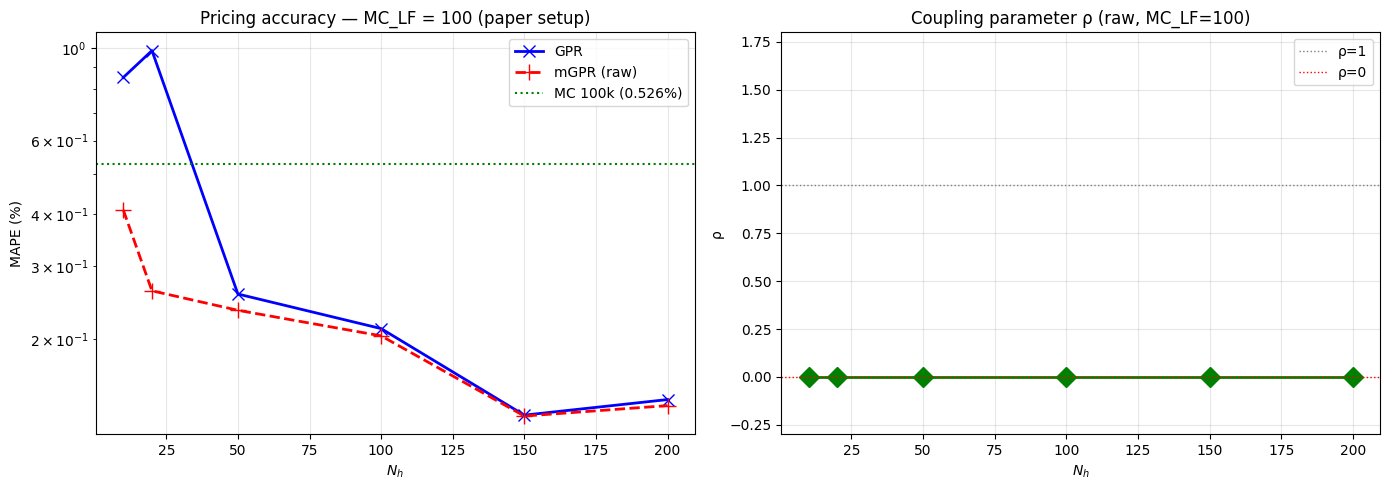

In [11]:
# === Section 7 plots ===

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- MAPE convergence ---
ax = axes[0]
mape_g = [results7[N]['gpr']['mape']  * 100 for N in N_hf_values]
mape_m = [results7[N]['mgpr']['mape'] * 100 for N in N_hf_values]
ax.plot(N_hf_values, mape_g, 'b-x', label='GPR', ms=9, lw=2)
ax.plot(N_hf_values, mape_m, 'r--+', label='mGPR (raw)', ms=11, lw=2)
ax.axhline(y=mape_mc*100, color='green', ls=':', lw=1.5, label=f'MC 100k ({mape_mc*100:.3f}%)')
ax.set_xlabel('$N_h$'); ax.set_ylabel('MAPE (%)'); ax.set_yscale('log')
ax.set_title('Pricing accuracy — MC_LF = 100 (paper setup)'); ax.legend(); ax.grid(alpha=0.3)

# --- rho ---
ax = axes[1]
rhos = [results7[N]['mgpr']['rho'] for N in N_hf_values]
ax.plot(N_hf_values, rhos, 'g-D', ms=10, lw=2)
ax.axhline(y=1.0, color='gray', ls=':', lw=1, label='ρ=1')
ax.axhline(y=0.0, color='red', ls=':', lw=1, label='ρ=0')
ax.set_xlabel('$N_h$'); ax.set_ylabel('ρ'); ax.set_ylim(-0.3, 1.8)
ax.set_title('Coupling parameter ρ (raw, MC_LF=100)'); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()


- **In pricing MAPE, mGPR (raw) is slightly better than GPR for small $N_h$**, especially at $N_h=10$ and $20$.
- **As $N_h$ increases, the gap becomes very small**, and both models behave almost the same.
- The estimated **coupling parameter stays at $\rho \approx 0$ for all $N_h$**, which means the model is **not using the low-fidelity signal**.
- So, under the **paper setup with $\mathrm{MC\_LF}=100$**, the raw AR(1) coupling **collapses**, and the multi-fidelity advantage is largely lost.
- In short: **there is a small pricing gain at very low $N_h$, but no meaningful multi-fidelity coupling, and the risk metrics do not improve consistently**.

In [12]:
# === Section 7: VaR / ES table ===

print(f"True VaR 99% = {var_99_true:.4f}  |  True ES 97.5% = {es_975_true:.4f}  |  V0 = {V0:.4f}")
print(f"\n{'N_h':>5} | {'GPR VaR':>9} {'mGPR VaR':>9} | {'GPR ES':>9} {'mGPR ES':>9} | "
      f"{'err_V_G':>8} {'err_V_M':>8} | {'err_E_G':>8} {'err_E_M':>8} | {'rho':>5}")
print("-" * 105)
for N in N_hf_values:
    g, m = results7[N]['gpr'], results7[N]['mgpr']
    evg = abs(g['var_99']-var_99_true)/V0*1e4; evm = abs(m['var_99']-var_99_true)/V0*1e4
    eeg = abs(g['es_975']-es_975_true)/V0*1e4; eem = abs(m['es_975']-es_975_true)/V0*1e4
    print(f"{N:>5} | {g['var_99']:>9.4f} {m['var_99']:>9.4f} | "
          f"{g['es_975']:>9.4f} {m['es_975']:>9.4f} | "
          f"{evg:>7.1f}b {evm:>7.1f}b | {eeg:>7.1f}b {eem:>7.1f}b | {m['rho']:>5.3f}")


True VaR 99% = 0.8502  |  True ES 97.5% = 0.8483  |  V0 = 5.5355

  N_h |   GPR VaR  mGPR VaR |    GPR ES   mGPR ES |  err_V_G  err_V_M |  err_E_G  err_E_M |   rho
---------------------------------------------------------------------------------------------------------
   10 |    0.8466    0.9083 |    0.8413    0.9078 |     6.5b   104.9b |    12.8b   107.5b | 0.001
   20 |    0.8024    0.9105 |    0.7965    0.9080 |    86.3b   108.9b |    93.7b   107.7b | 0.001
   50 |    0.8718    0.8864 |    0.8705    0.8852 |    39.0b    65.4b |    40.1b    66.6b | 0.001
  100 |    0.8629    0.8669 |    0.8615    0.8659 |    22.9b    30.2b |    23.8b    31.8b | 0.001
  150 |    0.8628    0.8648 |    0.8624    0.8646 |    22.8b    26.3b |    25.4b    29.3b | 0.001
  200 |    0.8508    0.8534 |    0.8503    0.8524 |     1.1b     5.8b |     3.5b     7.3b | 0.001


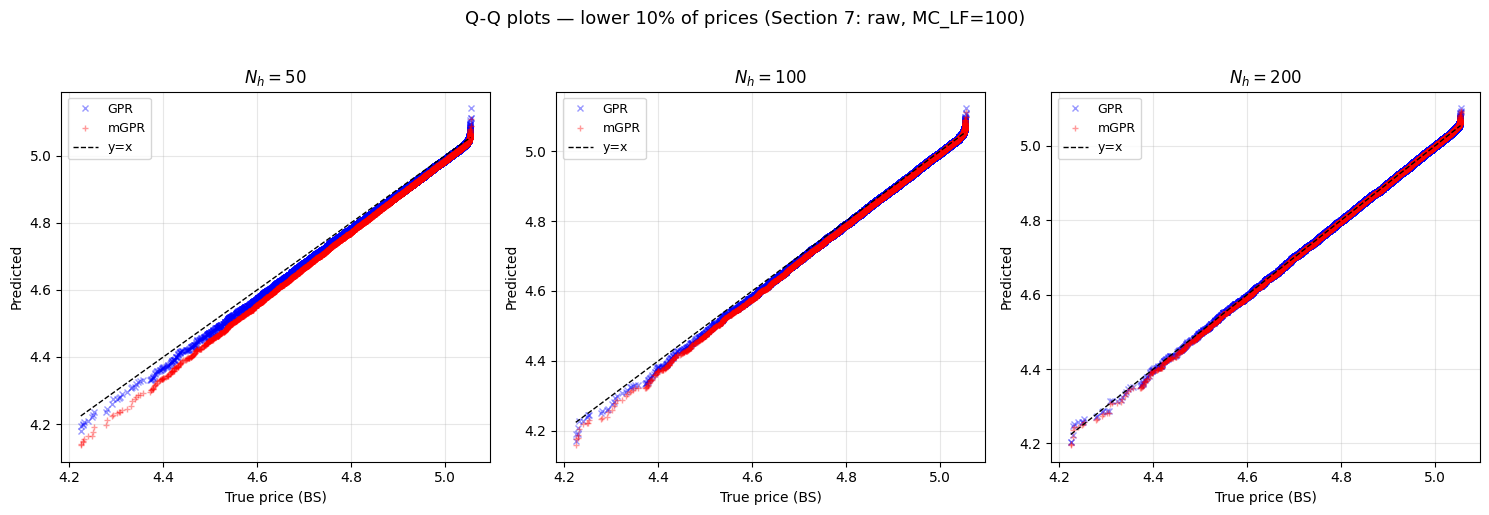

In [13]:
# === Section 7: Q-Q plots (lower 10% tail) ===

n_show = [50, 100, 200]
fig, axes = plt.subplots(1, len(n_show), figsize=(15, 5))
q10 = np.percentile(prices_true, 10)
mask = prices_true <= q10
true_tail = np.sort(prices_true[mask])

for ax, N in zip(axes, n_show):
    g_tail = np.sort(results7[N]['gpr']['preds'][mask])
    m_tail = np.sort(results7[N]['mgpr']['preds'][mask])
    ax.plot(true_tail, g_tail, 'bx', alpha=0.4, ms=4, label='GPR')
    ax.plot(true_tail, m_tail, 'r+', alpha=0.4, ms=4, label='mGPR')
    lims = [true_tail.min(), true_tail.max()]
    ax.plot(lims, lims, 'k--', lw=1, label='y=x')
    ax.set_xlabel('True price (BS)'); ax.set_ylabel('Predicted')
    ax.set_title(f'$N_h = {N}$'); ax.legend(fontsize=9); ax.grid(alpha=0.3)
fig.suptitle('Q-Q plots — lower 10% of prices (Section 7: raw, MC_LF=100)', y=1.02, fontsize=13)
plt.tight_layout(); plt.show()


- Both **GPR** and **mGPR** are very close to the diagonal, so the pricing fit is **good overall** in the lower 10% region.
- **mGPR and GPR are almost indistinguishable**, which is consistent with the previous result that **$\rho \approx 0$**.
- At $N_h = 50$, there is still a **small underestimation in the lower tail**, especially for the smallest prices.
- As $N_h$ increases to $100$ and $200$, the Q-Q plots become **tighter and more aligned with $y=x$**.
- In short: **more HF points improve tail calibration, but raw mGPR does not bring a clear advantage over GPR here**.

## 8. Sensitivity Analysis — Impact of LF Noise and De-Noising

Section 7 showed that $\rho \approx 0$ when using the paper-faithful formulation with MC\_LF = 100. We now investigate **why** and **how to fix it** through a 2×2 experiment:

| | MC\_LF = 100 | MC\_LF = 500 |
|---|---|---|
| **Raw $y_{l,\text{sub}}$** | Paper setup (expected: ρ ≈ 0) | Less noise (expected: ρ closer to 1) |
| **De-noised $\mu_l$** | Tests whether de-noising alone fixes ρ | Best coupling (expected: ρ ≈ 1) |

All four mGPR variants are compared against the same GPR baseline trained on HF only.


In [ ]:
# === Section 8: 2x2 sensitivity analysis ===
#
# Investigate whether the ρ ≈ 0 issue observed in Section 7 comes from:
# 1. MC noise in LF data (100 paths = ~15% noise)
# 2. Using raw y_lf_sub instead of de-noised posterior mean
#
# Factorial design: 2 LF fidelities × 2 training approaches
# - MC_LF = 100:    Noisy (paper setup, Section 7)
# - MC_LF = 500:    Cleaner (more LF paths to reduce noise)
# - raw:            y_hf - rho * y_lf_sub (Eq. A9)
# - denoised:       y_hf - rho * mu_l(X_hf) (de-noised variant)

# Define the 4 experimental configurations
configs = [
    ("raw_100",      100, fit_mgpr_raw),         # Paper-faithful: noisy LF, raw residual
    ("denoised_100", 100, fit_mgpr_denoised),    # De-noised residual at MC_LF=100
    ("raw_500",      500, fit_mgpr_raw),         # Less noisy LF, raw residual
    ("denoised_500", 500, fit_mgpr_denoised),    # De-noised residual at MC_LF=500
]

# Use consistent sample sizes as Section 7
N_hf_values_8 = [10, 20, 50, 100, 150, 200]
N_lf_fixed_8  = 200

# === Pre-generate both datasets (MC_LF=100 and MC_LF=500) ===
# Avoid re-generating repeatedly in the loop by pre-computing once
datasets = {}
for mc_lf in [100, 500]:
    print(f"\nGenerating dataset for MC_LF = {mc_lf}...")
    X_h, y_h, X_l, y_l = generate_training_data(
        S_shocked, N_hf=N_lf_fixed_8, N_lf=N_lf_fixed_8,
        K=K, T=T_mat, r=r, sigma=sigma, corr_matrix=corr_matrix,
        mc_hf=MC_HF, mc_lf=mc_lf, seed=SEED, verbose=True
    )
    datasets[mc_lf] = (X_h, y_h, X_l, y_l)

# === Run all 4 mGPR configurations ===
results8 = {name: {} for name, _, _ in configs}

for cfg_name, mc_lf, fit_fn in configs:
    # Retrieve pre-generated dataset for this MC_LF level
    X_h_all, y_h_all, X_l_all, y_l_all = datasets[mc_lf]
    print(f"\n{'='*50}")
    print(f"  Config: {cfg_name}")
    print(f"{'='*50}")

    # For each HF sample size (nested design)
    for N_hf in N_hf_values_8:
        # Extract nested training sets
        X_hf, y_hf = X_h_all[:N_hf], y_h_all[:N_hf]
        X_lf, y_lf = X_l_all.copy(), y_l_all.copy()

        # Train mGPR variant and evaluate on all 100k scenarios
        t0 = time.time()
        m = fit_fn(X_hf, y_hf, X_lf, y_lf, verbose=False)
        preds = predict_mgpr(m, S_shocked)
        t_m = time.time() - t0
        mape, var, es = evaluate_surrogate(preds, prices_true, V0)
        
        # Store results
        results8[cfg_name][N_hf] = dict(mape=mape, var_99=var, es_975=es, time=t_m, rho=m['rho'])
        print(f"  N_hf={N_hf:>3}: MAPE={mape*100:.4f}% | rho={m['rho']:.4f} | t={t_m:.0f}s")

# === Compute GPR baseline for comparison ===
# Use HF only (MC_LF=100 dataset), same as Section 7 setup
results8_gpr = {}
X_h_all_100 = datasets[100][0]
y_h_all_100 = datasets[100][1]
for N_hf in N_hf_values_8:
    gp, sc = fit_gpr_sklearn(X_h_all_100[:N_hf], y_h_all_100[:N_hf])
    preds_g = predict_gpr_sklearn(gp, sc, S_shocked)
    m_g, v_g, e_g = evaluate_surrogate(preds_g, prices_true, V0)
    results8_gpr[N_hf] = dict(mape=m_g, var_99=v_g, es_975=e_g)

print("\nDone.")



Generating dataset for MC_LF = 100...
Generating: N_hf=200, N_lf=200, mc_lf=100, mc_hf=100000
Done in 3.6s  |  corr(y_lf_sub, y_hf) = 0.2421

Generating dataset for MC_LF = 500...
Generating: N_hf=200, N_lf=200, mc_lf=500, mc_hf=100000
Done in 4.1s  |  corr(y_lf_sub, y_hf) = 0.4951

  Config: raw_100
  N_hf= 10: MAPE=0.4088% | rho=0.0006 | t=71s
  N_hf= 20: MAPE=0.2614% | rho=0.0006 | t=70s
  N_hf= 50: MAPE=0.2347% | rho=0.0006 | t=73s
  N_hf=100: MAPE=0.2037% | rho=0.0006 | t=73s
  N_hf=150: MAPE=0.1307% | rho=0.0006 | t=84s
  N_hf=200: MAPE=0.1385% | rho=0.0006 | t=95s

  Config: denoised_100
  N_hf= 10: MAPE=0.4561% | rho=1.3311 | t=58s
  N_hf= 20: MAPE=0.2831% | rho=1.3598 | t=52s
  N_hf= 50: MAPE=0.2429% | rho=1.0910 | t=57s
  N_hf=100: MAPE=0.2080% | rho=1.1924 | t=58s
  N_hf=150: MAPE=0.1282% | rho=1.2409 | t=64s
  N_hf=200: MAPE=0.1377% | rho=1.1844 | t=77s

  Config: raw_500
  N_hf= 10: MAPE=0.4072% | rho=0.0006 | t=53s
  N_hf= 20: MAPE=0.2608% | rho=0.0006 | t=53s
  N_hf= 50

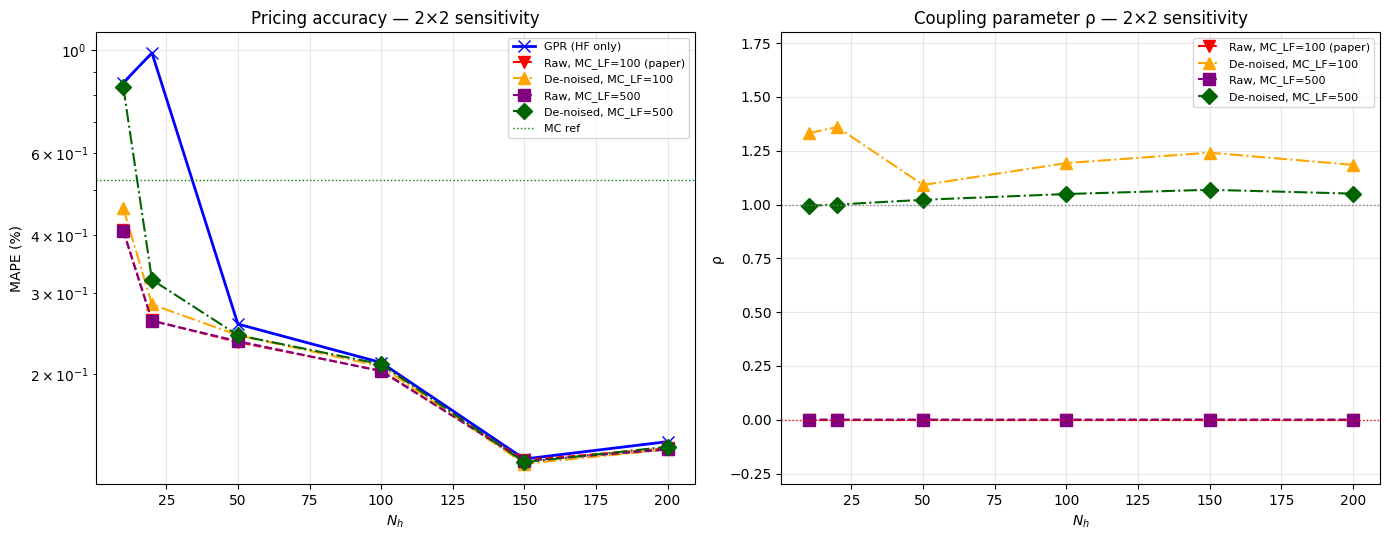

In [15]:
# === Section 8 plots: MAPE + rho for all 4 variants ===

styles = {
    "raw_100":      ("Raw, MC_LF=100 (paper)",  "r", "--", "v"),
    "denoised_100": ("De-noised, MC_LF=100",    "orange", "-.", "^"),
    "raw_500":      ("Raw, MC_LF=500",           "purple", "--", "s"),
    "denoised_500": ("De-noised, MC_LF=500",     "darkgreen", "-.", "D"),
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# --- MAPE ---
ax = axes[0]
gpr_mape = [results8_gpr[N]['mape']*100 for N in N_hf_values_8]
ax.plot(N_hf_values_8, gpr_mape, 'b-x', label='GPR (HF only)', ms=8, lw=2)
for name, (lbl, col, ls, mk) in styles.items():
    mapes = [results8[name][N]['mape']*100 for N in N_hf_values_8]
    ax.plot(N_hf_values_8, mapes, color=col, ls=ls, marker=mk, label=lbl, ms=8, lw=1.5)
ax.axhline(y=mape_mc*100, color='green', ls=':', lw=1, label=f'MC ref')
ax.set_xlabel('$N_h$'); ax.set_ylabel('MAPE (%)'); ax.set_yscale('log')
ax.set_title('Pricing accuracy — 2×2 sensitivity'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# --- rho ---
ax = axes[1]
for name, (lbl, col, ls, mk) in styles.items():
    rhos = [results8[name][N]['rho'] for N in N_hf_values_8]
    ax.plot(N_hf_values_8, rhos, color=col, ls=ls, marker=mk, label=lbl, ms=8, lw=1.5)
ax.axhline(y=1.0, color='gray', ls=':', lw=1); ax.axhline(y=0.0, color='red', ls=':', lw=1)
ax.set_xlabel('$N_h$'); ax.set_ylabel('ρ'); ax.set_ylim(-0.3, 1.8)
ax.set_title('Coupling parameter ρ — 2×2 sensitivity'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()


- **All mGPR variants improve over HF-only GPR when $N_h$ is small**, especially at $N_h=10$ and $20$.
- **The gain becomes very small as $N_h$ increases**, and all methods are nearly identical from $N_h \ge 50$.
- The key result is on the **coupling parameter $\rho$**:
  - **Raw variants** keep **$\rho \approx 0$** for both $\mathrm{MC\_LF}=100$ and $500$.
  - **De-noised variants** recover a **meaningful coupling**, with **$\rho \approx 1$ to $1.35$**.
- This shows that **increasing $\mathrm{MC\_LF}$ alone does not fix the raw formulation**. The main issue is the **use of noisy LF observations in the residual**.
- **De-noising restores the multi-fidelity link**, while **raw fitting collapses to a near single-fidelity behavior**.
- In short: **the real fix is de-noising, not just more LF Monte Carlo paths**.

In [16]:
# === Section 8: Summary table ===

print(f"{'Config':<20} | " + " | ".join(f"N={N:>3}" for N in N_hf_values_8) + " |")
print("-" * 90)

# GPR baseline
mapes = [f"{results8_gpr[N]['mape']*100:.3f}" for N in N_hf_values_8]
print(f"{'GPR (baseline)':<20} | " + " | ".join(f"{m:>5}" for m in mapes) + " |")

for name in ["raw_100", "denoised_100", "raw_500", "denoised_500"]:
    mapes = [f"{results8[name][N]['mape']*100:.3f}" for N in N_hf_values_8]
    rhos  = [f"{results8[name][N]['rho']:.2f}" for N in N_hf_values_8]
    print(f"{name:<20} | " + " | ".join(f"{m:>5}" for m in mapes) + " | MAPE %")
    print(f"{'  └─ rho':<20} | " + " | ".join(f"{r:>5}" for r in rhos) + " |")


Config               | N= 10 | N= 20 | N= 50 | N=100 | N=150 | N=200 |
------------------------------------------------------------------------------------------
GPR (baseline)       | 0.851 | 0.988 | 0.257 | 0.212 | 0.131 | 0.143 |
raw_100              | 0.409 | 0.261 | 0.235 | 0.204 | 0.131 | 0.138 | MAPE %
  └─ rho             |  0.00 |  0.00 |  0.00 |  0.00 |  0.00 |  0.00 |
denoised_100         | 0.456 | 0.283 | 0.243 | 0.208 | 0.128 | 0.138 | MAPE %
  └─ rho             |  1.33 |  1.36 |  1.09 |  1.19 |  1.24 |  1.18 |
raw_500              | 0.407 | 0.261 | 0.236 | 0.203 | 0.130 | 0.138 | MAPE %
  └─ rho             |  0.00 |  0.00 |  0.00 |  0.00 |  0.00 |  0.00 |
denoised_500         | 0.833 | 0.320 | 0.243 | 0.210 | 0.129 | 0.140 | MAPE %
  └─ rho             |  0.99 |  1.00 |  1.02 |  1.05 |  1.07 |  1.05 |


## 9. Validation: American Put Option (Section 4.3 of the Paper)

To validate our implementation independently of the low-fidelity Monte Carlo noise issue, we reproduce the American put experiment of Section 4.3 of the paper, where:

- **High-fidelity (HF):** American put priced by a binomial tree with 100 time steps.
- **Low-fidelity (LF):** European put priced by the Black-Scholes formula, which is deterministic and noise-free.

This is a favorable setting for multi-fidelity modelling because the LF model is available in closed form and remains structurally related to the HF target. In contrast with Sections 7 and 8, the LF source here contains no Monte Carlo noise. As a result, the raw AR(1) formulation is expected to behave well, and the gap between raw and de-noised variants should be small in practice.

**Setup.** We use strike $K = 62$, risk-free rate $r = 0.05$, volatility $\sigma = 0.20$, and maturity $T = 1$ year. The test set is a fixed random sample of 2000 values of the underlying asset price in $[1,140]$. For each HF budget $N_h \in \{3,5,7,10,15,20\}$, the HF training points are chosen as an evenly spaced grid over $[1,140]$. The LF design starts from a fixed 20-point regular grid on $[1,140]$ and is then augmented with the HF locations so that the inclusion condition $X_h \subset X_l$ required by the raw mGPR implementation is satisfied.

### High-fidelity price: American put

The HF target is the American put price
$$
P^{\mathrm{Am}}(S,t),
$$
which satisfies the early-exercise principle
$$
P^{\mathrm{Am}}(S,t)=\max\Bigl(K-S,\;e^{-r\Delta t}\,\mathbb{E}[P^{\mathrm{Am}}(S_{t+\Delta t},t+\Delta t)\mid S_t=S]\Bigr).
$$

In practice, this price is approximated with a Cox-Ross-Rubinstein binomial tree with $N=100$ time steps. Let
$$
\Delta t=\frac{T}{N}, \qquad
u=e^{\sigma\sqrt{\Delta t}}, \qquad
d=e^{-\sigma\sqrt{\Delta t}}, \qquad
p=\frac{e^{r\Delta t}-d}{u-d}.
$$


At maturity, the terminal payoff is
$$
P^{\mathrm{Am}}_N(S_j)=\max(K-S_j,0),
$$
and backward induction is performed through
$$
P^{\mathrm{Am}}_n(S_j)
=
\max\left(
K-S_j,\;
e^{-r\Delta t}\left[p\,P^{\mathrm{Am}}_{n+1}(S_j u)+(1-p)\,P^{\mathrm{Am}}_{n+1}(S_j d)\right]
\right).
$$

The value at time $t=0$ is the root node of the tree.

### Low-fidelity price: European put

The LF model is the European put price given by the Black-Scholes formula:
$$
P^{\mathrm{Eu}}(S,0)=K e^{-rT}\Phi(-d_2)-S\Phi(-d_1),
$$
where
$$
d_1=\frac{\ln(S/K)+\left(r+\tfrac{1}{2}\sigma^2\right)T}{\sigma\sqrt{T}},
\qquad
d_2=d_1-\sigma\sqrt{T},
$$
and $\Phi(\cdot)$ denotes the cumulative distribution function of the standard normal distribution.

Thus, in this validation setting, the multi-fidelity relation is built between the deterministic LF function
$$
f_L(S)=P^{\mathrm{Eu}}(S,0)
$$
and the HF target
$$
f_H(S)=P^{\mathrm{Am}}(S,0).
$$

In [ ]:
# === American and European put pricing engines ===
# 
# Section 9 validation: test the mGPR implementation on American put options.
# - LF: European put (Black-Scholes formula) — deterministic, no MC noise
# - HF: American put (binomial tree) — numerical approximation
# This addresses the key question: is the rho ≈ 0 issue from mc code or LF noise?

def price_european_put_bs(S, K, T, r, sigma):
    """
    Black-Scholes European put price.
    
    Formula: P = K*exp(-r*T)*N(-d2) - S*N(-d1)
    where d1 = [ln(S/K) + (r + sigma^2/2)*T] / (sigma*sqrt(T))
          d2 = d1 - sigma*sqrt(T)
    
    Parameters
    ----------
    S : float or array
        Current underlying price (scalar or batch).
    K, T, r, sigma : float
        Strike, maturity, risk-free rate, volatility.
    
    Returns
    -------
    price : float or array
        European put price.
    """
    S = np.asarray(S, dtype=np.float64)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)


def price_american_put_tree(S, K, T, r, sigma, n_steps=100):
    """
    American put price using Cox-Ross-Rubinstein binomial tree.
    
    This is the HF reference for validation. The binomial tree recursively prices
    the option by:
    1. Generating all terminal stock values at maturity
    2. Computing terminal payoffs: max(K - S_T, 0)
    3. Working backward through time, at each node taking:
       max(intrinsic value, discounted expected value of continuation)
    This automatically incorporates early exercise opportunities.
    
    Parameters
    ----------
    S : float or array
        Current underlying price.
    K, T, r, sigma : float
        Strike, maturity, risk-free rate, volatility.
    n_steps : int, optional
        Number of binomial tree steps (default 100).
    
    Returns
    -------
    price : float or array
        American put price.
    """
    S = np.asarray(S, dtype=np.float64)
    scalar = (S.ndim == 0)
    S = np.atleast_1d(S)
    
    # Tree parameters
    dt = T / n_steps
    u = np.exp(sigma * np.sqrt(dt))  # Up factor
    d_f = 1.0 / u                    # Down factor
    p = (np.exp(r * dt) - d_f) / (u - d_f)  # Risk-neutral probability
    disc = np.exp(-r * dt)           # Discount factor

    prices = np.empty(len(S))
    for idx, s0 in enumerate(S):
        # --- Terminal payoffs at maturity ---
        # Generate all terminal stock prices: s0 * u^j * d^(n-j), j=0..n
        ST = s0 * u ** np.arange(n_steps, -1, -1) * d_f ** np.arange(0, n_steps + 1)
        V = np.maximum(K - ST, 0.0)
        
        # --- Backward induction through the tree ---
        # At each time step, move from leaves toward root
        for i in range(n_steps - 1, -1, -1):
            # Compute stock prices at this level
            Si = s0 * u ** np.arange(i, -1, -1) * d_f ** np.arange(0, i + 1)
            
            # Compute value: max(intrinsic, discounted expected continuation)
            # V[:-1] and V[1:] are up/down branches from previous step
            V = disc * (p * V[:-1] + (1 - p) * V[1:])
            
            # Apply early exercise: take max with intrinsic value at this node
            V = np.maximum(V, K - Si)
        
        prices[idx] = V[0]  # Root node value
    
    return float(prices[0]) if scalar else prices


# === Quick validation: check option prices and early exercise premium ===
S_test = 100.0
K_am, r_am, sigma_am, T_am = 62.0, 0.05, 0.20, 1.0

# Price at the same spot for both European and American puts
p_eu = price_european_put_bs(S_test, K_am, T_am, r_am, sigma_am)
p_am = price_american_put_tree(S_test, K_am, T_am, r_am, sigma_am, 100)

print(f"At S={S_test}: European put = {p_eu:.4f}, American put = {p_am:.4f}")
print(f"Early exercise premium = {p_am - p_eu:.4f}")


At S=100.0: European put = 0.0197, American put = 0.0194
Early exercise premium = -0.0003


In [ ]:
# === Section 9: American put — GPR vs mGPR ===
#
# Validation on American put option with deterministic LF model.
# This tests whether the mGPR implementation is correct and whether the rho ≈ 0 issue
# in Sections 7-8 is due to code bugs or purely due to MC noise in the LF source.
# Since LF (European put) is noise-free, rho should be clearly non-zero if the code is correct.

# Option parameters (consistent across all experiments)
K_am, r_am, sigma_am, T_am = 62.0, 0.05, 0.20, 1.0
n_steps_hf = 100  # Number of steps in binomial tree for HF pricing

# === Generate test set ===
# Use 2000 random asset prices in [1, 140] to evaluate both models
rng_am = np.random.default_rng(SEED)
S_test_am = rng_am.uniform(1, 140, size=2000)
y_test_am = price_american_put_tree(S_test_am, K_am, T_am, r_am, sigma_am, n_steps_hf)

# === Fixed LF design ===
# Create a baseline grid of 20 evenly spaced points in [1, 140]
# This is the LF set that will be reused in all experiments
N_lf_am = 20
S_lf_am = np.linspace(1, 140, N_lf_am)
y_lf_am = price_european_put_bs(S_lf_am, K_am, T_am, r_am, sigma_am)

# === Main convergence experiment ===
# For each HF sample size, test GPR vs mGPR on this noise-free problem
N_hf_am_values = [3, 5, 7, 10, 15, 20]

results9 = {}
for N_hf in N_hf_am_values:
    # --- Generate HF training points ---
    # Use independent evenly-spaced grid (not a subset of LF grid)
    # This is more realistic: HF and LF are acquired independently
    S_hf_am = np.linspace(1, 140, N_hf)
    y_hf_am = price_american_put_tree(S_hf_am, K_am, T_am, r_am, sigma_am, n_steps_hf)

    # --- Construct combined LF set for mGPR ===
    # mGPR requires X_hf ⊂ X_lf. If HF points don't fall on LF grid,
    # we create a union and augment with the missing HF points
    S_lf_union = np.union1d(S_lf_am, S_hf_am)
    y_lf_union = price_european_put_bs(S_lf_union, K_am, T_am, r_am, sigma_am)

    # Identify which points in the union are the original HF training points
    hf_mask = np.isin(S_lf_union, S_hf_am)

    # Reshape for mGPR (expects 2D arrays)
    X_hf = S_hf_am.reshape(-1, 1)
    X_lf = S_lf_union.reshape(-1, 1)
    X_test = S_test_am.reshape(-1, 1)

    # --- Reorder LF set to satisfy X_hf = X_lf[:N_hf] constraint ---
    # mGPR training functions expect HF points to be the first N_hf rows
    hf_idx = np.where(hf_mask)[0]           # Indices of HF points in union
    lf_only_idx = np.where(~hf_mask)[0]     # Indices of LF-only points
    reorder = np.concatenate([hf_idx, lf_only_idx])  # Reorder: HF first, then LF-only
    X_lf = X_lf[reorder]
    y_lf_reord = y_lf_union[reorder]

    # --- Train standard GPR (HF only) ---
    gp, sc = fit_gpr_sklearn(X_hf, y_hf_am)
    preds_g = predict_gpr_sklearn(gp, sc, X_test)
    mae_g = np.mean(np.abs(preds_g - y_test_am))

    # --- Train multi-fidelity mGPR (raw version) ---
    # Note: raw = denoised for this case since LF is noise-free
    mgpr = fit_mgpr_raw(X_hf, y_hf_am, X_lf, y_lf_reord, verbose=False)
    preds_m = predict_mgpr(mgpr, X_test)
    mae_m = np.mean(np.abs(preds_m - y_test_am))

    # --- Store results ---
    results9[N_hf] = dict(mae_g=mae_g, mae_m=mae_m, rho=mgpr['rho'],
                          preds_g=preds_g, preds_m=preds_m,
                          S_hf=S_hf_am, y_hf=y_hf_am,
                          S_lf=S_lf_union, y_lf=y_lf_union)
    print(f"N_hf={N_hf:>2}: MAE_GPR={mae_g:.4f}, MAE_mGPR={mae_m:.4f}, rho={mgpr['rho']:.4f}")


N_hf= 3: MAE_GPR=18.2410, MAE_mGPR=0.4563, rho=1.0518
N_hf= 5: MAE_GPR=0.6154, MAE_mGPR=0.2647, rho=1.0630
N_hf= 7: MAE_GPR=0.3229, MAE_mGPR=0.1067, rho=1.0571
N_hf=10: MAE_GPR=0.0648, MAE_mGPR=0.0481, rho=1.0575
N_hf=15: MAE_GPR=0.0176, MAE_mGPR=0.0192, rho=1.0552
N_hf=20: MAE_GPR=0.0054, MAE_mGPR=0.0051, rho=1.0568


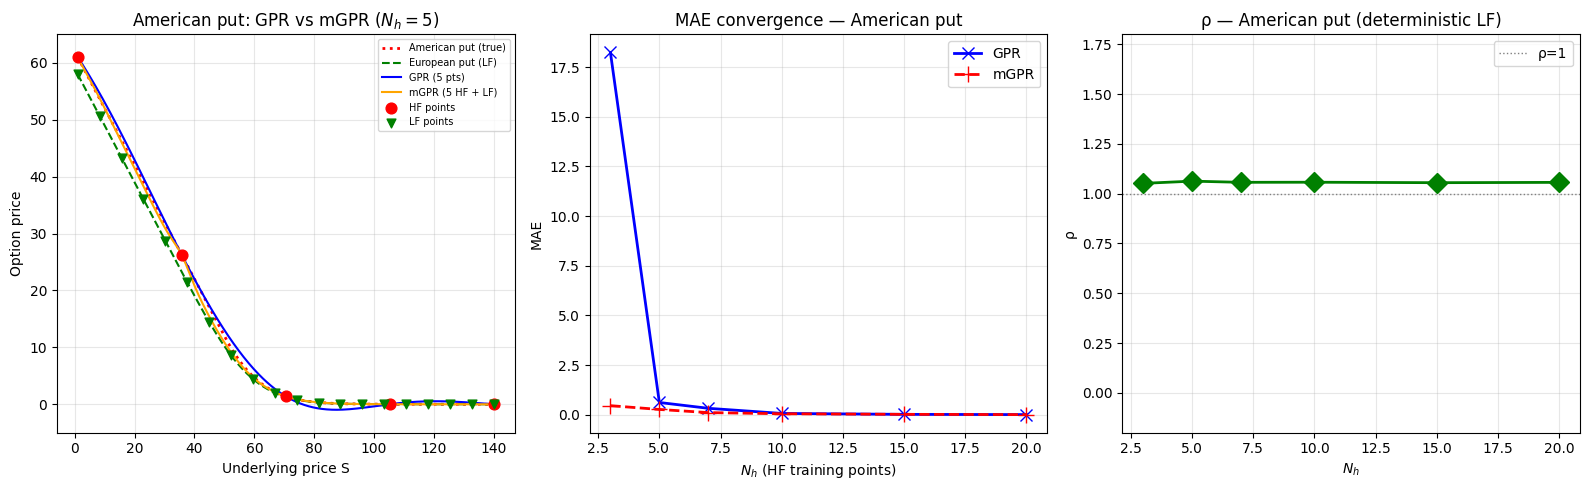


 N_hf |   MAE GPR |  MAE mGPR |    rho
------------------------------------------
    3 |   18.2410 |    0.4563 |  1.052
    5 |    0.6154 |    0.2647 |  1.063
    7 |    0.3229 |    0.1067 |  1.057
   10 |    0.0648 |    0.0481 |  1.058
   15 |    0.0176 |    0.0192 |  1.055
   20 |    0.0054 |    0.0051 |  1.057


In [22]:
# === Section 9: American put plots ===

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Left: price functions (N_hf = 5) ---
ax = axes[0]
S_fine = np.linspace(1, 140, 500)
y_am_fine = price_american_put_tree(S_fine, K_am, T_am, r_am, sigma_am, n_steps_hf)
y_eu_fine = price_european_put_bs(S_fine, K_am, T_am, r_am, sigma_am)

r9_5 = results9[5]
# Rebuild models for fine-grid prediction
S_lf_u5 = np.union1d(S_lf_am, r9_5['S_hf'])
y_lf_u5 = price_european_put_bs(S_lf_u5, K_am, T_am, r_am, sigma_am)
hf_mask5 = np.isin(S_lf_u5, r9_5['S_hf'])
reorder5 = np.concatenate([np.where(hf_mask5)[0], np.where(~hf_mask5)[0]])

mgpr_5 = fit_mgpr_raw(r9_5['S_hf'].reshape(-1,1), r9_5['y_hf'],
                       S_lf_u5[reorder5].reshape(-1,1), y_lf_u5[reorder5], verbose=False)
pred_mgpr_fine = predict_mgpr(mgpr_5, S_fine.reshape(-1,1))

gp5, sc5 = fit_gpr_sklearn(r9_5['S_hf'].reshape(-1,1), r9_5['y_hf'])
pred_gpr_fine = predict_gpr_sklearn(gp5, sc5, S_fine.reshape(-1,1))

ax.plot(S_fine, y_am_fine, 'r:', lw=2, label='American put (true)')
ax.plot(S_fine, y_eu_fine, 'g--', lw=1.5, label='European put (LF)')
ax.plot(S_fine, pred_gpr_fine, 'b-', lw=1.5, label='GPR (5 pts)')
ax.plot(S_fine, pred_mgpr_fine, color='orange', lw=1.5, label='mGPR (5 HF + LF)')
ax.scatter(r9_5['S_hf'], r9_5['y_hf'], c='red', s=60, zorder=5, marker='o', label='HF points')
ax.scatter(S_lf_am, y_lf_am, c='green', s=40, zorder=5, marker='v', label='LF points')
ax.set_xlabel('Underlying price S'); ax.set_ylabel('Option price')
ax.set_title('American put: GPR vs mGPR ($N_h = 5$)')
ax.legend(fontsize=7); ax.grid(alpha=0.3); ax.set_ylim(-5, 65)

# --- Middle: MAE convergence ---
ax = axes[1]
maes_g = [results9[N]['mae_g'] for N in N_hf_am_values]
maes_m = [results9[N]['mae_m'] for N in N_hf_am_values]
ax.plot(N_hf_am_values, maes_g, 'b-x', label='GPR', ms=9, lw=2)
ax.plot(N_hf_am_values, maes_m, 'r--+', label='mGPR', ms=11, lw=2)
ax.set_xlabel('$N_h$ (HF training points)'); ax.set_ylabel('MAE')
ax.set_title('MAE convergence — American put'); ax.legend(); ax.grid(alpha=0.3)

# --- Right: rho ---
ax = axes[2]
rhos_am = [results9[N]['rho'] for N in N_hf_am_values]
ax.plot(N_hf_am_values, rhos_am, 'g-D', ms=10, lw=2)
ax.axhline(y=1.0, color='gray', ls=':', lw=1, label='ρ=1')
ax.set_xlabel('$N_h$'); ax.set_ylabel('ρ')
ax.set_title('ρ — American put (deterministic LF)'); ax.legend(); ax.grid(alpha=0.3)
ax.set_ylim(-0.2, 1.8)

plt.tight_layout(); plt.show()

# Table
print(f"\n{'N_hf':>5} | {'MAE GPR':>9} | {'MAE mGPR':>9} | {'rho':>6}")
print("-" * 42)
for N in N_hf_am_values:
    r = results9[N]
    print(f"{N:>5} | {r['mae_g']:>9.4f} | {r['mae_m']:>9.4f} | {r['rho']:>6.3f}")


- In this deterministic low-fidelity American put example, **mGPR clearly improves over GPR when $N_h$ is very small**.
- With only **$N_h=3$**, GPR has a **large error**, while mGPR is already **much more accurate**.
- As $N_h$ increases, **both methods converge quickly**, and the gap becomes very small.
- The estimated **coupling stays stable around $\rho \approx 1.05$**, which confirms a **strong and meaningful low-high fidelity relationship**.
- This is the expected behavior of AR(1) co-kriging when the LF signal is **clean and informative**.
- In short: **mGPR works well here, especially in the low-data regime, because the LF model is deterministic and well coupled to the HF model**.

## 10. Discussion

### 10.1 Section 7: Paper-Faithful Reproduction (MC\_LF = 100, Raw $y_{l,\text{sub}}$)

With MC\_LF = 100, the low-fidelity prices carry ~15% relative noise (cf. sanity check). When optimizing $\rho$ using the raw LF observations, the marginal likelihood objective prefers $\rho \approx 0$: at $\rho = 0$ the residual equals the smooth $y_h$, while at $\rho = 1$ it inherits all the LF noise. This is mathematically correct — the optimizer minimizes negative log-likelihood — but it defeats the multi-fidelity purpose because the LF data is effectively ignored.

Despite this, both GPR and mGPR achieve good pricing accuracy and converge as $N_h$ increases, confirming that GP surrogates provide massive speed-ups over full repricing.

### 10.2 Section 8: Sensitivity Analysis

The 2×2 experiment highlights two main findings.

1. **De-noising rescues $\rho$.**  
   Replacing the raw low-fidelity observations $y_{l,\text{sub}}$ by the LF GP posterior mean $\mu_l(X_h)$ removes the Monte Carlo noise from the residual construction. In both MC\_LF = 100 and MC\_LF = 500, this leads to stable and meaningful estimates of $\rho$, close to $1$ in the cleaner setting.

2. **Increasing MC\_LF alone does not rescue the raw version.**  
   In the current experiments, increasing MC\_LF from 100 to 500 improves the correlation between LF and HF prices, but the raw formulation still returns $\rho \approx 0$. Therefore, in our notebook, the main improvement comes from de-noising rather than from simply increasing the number of low-fidelity Monte Carlo paths.

From a pricing-accuracy point of view, the de-noised variant does not uniformly dominate the raw version in MAPE, but it restores an interpretable multi-fidelity coupling. Therefore, the main conclusion of Section 8 is that de-noising is the most reliable way to recover a meaningful AR(1) relation when the LF source is noisy.

### 10.3 American Put Validation

The American put experiment confirms that the multi-fidelity implementation behaves correctly in a deterministic setting. In this case, the low-fidelity source is the European put price given by the Black-Scholes formula, while the high-fidelity target is the American put price computed by a binomial tree. Since the low-fidelity model is smooth and noise-free, this experiment provides a clean validation of the AR(1) multi-fidelity construction.

The main observations are:

- The estimated scaling parameter $\rho$ remains positive and stable, with values close to $1.05$ for all tested values of $N_h$.
- mGPR clearly improves over standard GPR when the number of HF points is small.
- As $N_h$ increases, the difference between GPR and mGPR becomes much smaller.
- At large $N_h$, both methods achieve very similar errors, showing that the main advantage of mGPR is in the low-data regime.

Overall, this validation supports that the implementation is correct. It also suggests that the collapse to $\rho \approx 0$ observed in the noisy Monte Carlo experiments is not caused by a coding error, but by the quality of the low-fidelity source.

### 10.4 Consistency with the Paper

The paper achieves good mGPR performance even with MC\_LF = 100 (Section 6.2). Several factors may explain this:
- Their specific market parameters may produce a wider price range across scenarios, improving the signal-to-noise ratio.
- Their use of the emukit package may handle the co-kriging optimization differently.
- The paper's full portfolio experiments (Section 6.3, 20 assets, 500 derivatives) represent the setting where mGPR truly shines — the pricing surface is high-dimensional and the standard GPR struggles.

### 10.5 When Does mGPR Add Value?

| Scenario | mGPR advantage | Our evidence |
|---|---|---|
| Deterministic LF (analytical formula) | Strong for small $N_h$, small for large $N_h$ | Section 9: American put |
| Noisy MC LF, few paths, raw | Weak ($\rho \to 0$) | Section 7 |
| Noisy MC LF, de-noised | Restores meaningful coupling; pricing gains are mixed | Section 8 |
| High-dimensional surface | Likely strong (paper Sec. 6.3) | Not tested |


## Future Perspectives

In our opinion, we also would like to try:

- Apply the approach to more realistic portfolios and real market data.
- Test other multi-fidelity or noise-aware models.
- Study better budget allocation between low-fidelity and high-fidelity simulations.

## 11. Conclusion

We reproduced and extended the experiments of Lehdili, Oswald and Nguyen (2025) on multi-fidelity Gaussian process regression for market risk calculation. The main findings of this notebook are the following.

1. **Paper-faithful reproduction** (Section 7):
    We implemented the AR(1) co-kriging model as described in Appendix B.2 with MC\_LF = 100. In this setting, the estimated coupling parameter satisfies $\rho \approx 0$, meaning that the raw low-fidelity signal is effectively ignored. This indicates that, when the LF source is strongly affected by Monte Carlo noise, the paper-faithful residual construction may fail to recover a useful multi-fidelity coupling.

2. **Sensitivity analysis and diagnosis** (Section 8):
   Through a 2×2 experiment combining raw versus de-noised LF signals and MC\_LF = 100 versus 500, we found that de-noising the LF signal through the LF GP posterior mean consistently restores meaningful values of $\rho$. In contrast, simply increasing MC\_LF from 100 to 500 was not sufficient to rescue the raw formulation in our notebook. This suggests that the main difficulty comes from using noisy raw LF observations inside the AR(1) residual.

3. **Validation in a deterministic setting** (Section 9): 
   The American put experiment, where the LF model is the deterministic Black-Scholes European put and the HF model is the American put computed by a binomial tree, confirms that the implementation behaves correctly in a clean setting. In this case, $\rho$ remains positive and stable, and mGPR clearly improves over standard GPR when the number of HF points is small. This provides strong evidence that the $\rho \approx 0$ behaviour observed in Section 7 is related to the noisy LF source rather than to a coding error.

4. **Practical insight**:
   The experiments show that the success of mGPR depends strongly on the quality of the low-fidelity source. When the LF model is deterministic or sufficiently smooth, mGPR provides useful structural information and improves performance in the low-data regime. When the LF source is noisy Monte Carlo, replacing raw $y_{l,\text{sub}}$ by the LF GP posterior mean is a practical way to recover an interpretable multi-fidelity relation, even if this does not always lead to uniformly better pricing errors.

Overall, both GPR and mGPR surrogates provide substantial computational savings compared with full repricing. In our experiments, GPR delivers good pricing and risk accuracy across the tested settings, while mGPR performs well when the low-fidelity source is reliable or de-noised. Under the raw noisy LF setting of Section 7, mGPR still gives reasonable pricing accuracy, but the risk metrics do not improve consistently because the coupling collapses to $\rho \approx 0$. The main added value of the multi-fidelity approach therefore appears when the LF source contains reliable structural information and the number of HF observations is limited.

### References

- Lehdili, N., Oswald, P., & Nguyen, H. D. (2025). *Performance-Enhancing Market Risk Calculation Through Gaussian Process Regression and Multi-Fidelity Modeling*. Computation, 13(6), 134.
- Kennedy, M. C., & O'Hagan, A. (2000). *Predicting the output from a complex computer code when fast approximations are available*. Biometrika, 87(1), 1–13.
- Rasmussen, C. E., & Williams, C. K. I. (2006). *Gaussian Processes for Machine Learning*. MIT Press.
- Le Gratiet, L. (2013). *Multi-Fidelity Gaussian Process Regression for Computer Experiments*. PhD Thesis, Université Paris-Diderot.
